# Overwatch — Server Log Anomaly Detection
### Unsupervised threat detection on real NASA-HTTP access logs (Isolation Forest)

This notebook walks through the full pipeline: dataset inspection → parsing →
exploratory analysis → feature engineering → Isolation Forest training →
anomaly-score analysis → visualizations → example detections → conclusions.

**Dataset:** the real NASA-HTTP access log (`data/raw/access.log`), August 1995,
~1.57 million requests, standard Apache Common Log Format. This is genuine
public web traffic, not a security-incident dataset — see the Conclusions
section for what that means for interpreting results.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from log_parser import parse_log_file
from feature_engineering import build_features, FEATURE_COLUMNS
from report_generator import build_json_report, build_text_report

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 80)


## 1. Dataset Inspection

In [2]:
LOG_PATH = '../data/raw/access.log'

with open(LOG_PATH, 'r', errors='replace') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 4:
            break


in24.inetnebr.com - - [01/Aug/1995:00:00:01 -0400] "GET /shuttle/missions/sts-68/news/sts-68-mcc-05.txt HTTP/1.0" 200 1839
uplherc.upl.com - - [01/Aug/1995:00:00:07 -0400] "GET / HTTP/1.0" 304 0
uplherc.upl.com - - [01/Aug/1995:00:00:08 -0400] "GET /images/ksclogo-medium.gif HTTP/1.0" 304 0
uplherc.upl.com - - [01/Aug/1995:00:00:08 -0400] "GET /images/MOSAIC-logosmall.gif HTTP/1.0" 304 0
uplherc.upl.com - - [01/Aug/1995:00:00:08 -0400] "GET /images/USA-logosmall.gif HTTP/1.0" 304 0


Standard Common Log Format: `host - - [timestamp] "METHOD path HTTP/ver" status size`.
No referrer/user-agent (predates the "combined" log format). A handful of lines are
malformed (embedded quotes/HTML in the request field) or corrupted binary — the parser
handles both with a strict-then-loose regex fallback rather than silently dropping them,
and now preserves the **full** malformed request content in `path` (previously the loose
fallback truncated everything after the first space; it now keeps every embedded quote/
HTML/payload character, only stripping a trailing `HTTP/x.y` token if present). Rows parsed
via the loose fallback are flagged with `malformed_request=True`. `raw_line` is always kept
byte-for-byte unchanged regardless of which path was used.

## 2. Log Parsing

In [3]:
df, stats = parse_log_file(LOG_PATH)
print(stats.summary())
print(f"Parsed rows: {len(df):,}")
df.head()


[log_parser] total_lines=1569898 parsed_strict=1566297 parsed_loose=3591 dropped=10
total_lines=1569898 parsed_strict=1566297 parsed_loose=3591 dropped=10
Parsed rows: 1,569,888


,ip,method,path,status,size,malformed_request,raw_line,timestamp
0,in24.inetnebr.com,GET,/shuttle/missions/sts-68/news/sts-68-mcc-05.txt,200,1839,False,"in24.inetnebr.com - - [01/Aug/1995:00:00:01 -0400] ""GET /shuttle/missions/st...",1995-08-01 00:00:01-04:00
1,uplherc.upl.com,GET,/,304,0,False,"uplherc.upl.com - - [01/Aug/1995:00:00:07 -0400] ""GET / HTTP/1.0"" 304 0",1995-08-01 00:00:07-04:00
2,uplherc.upl.com,GET,/images/ksclogo-medium.gif,304,0,False,"uplherc.upl.com - - [01/Aug/1995:00:00:08 -0400] ""GET /images/ksclogo-medium...",1995-08-01 00:00:08-04:00
3,uplherc.upl.com,GET,/images/MOSAIC-logosmall.gif,304,0,False,"uplherc.upl.com - - [01/Aug/1995:00:00:08 -0400] ""GET /images/MOSAIC-logosma...",1995-08-01 00:00:08-04:00
4,uplherc.upl.com,GET,/images/USA-logosmall.gif,304,0,False,"uplherc.upl.com - - [01/Aug/1995:00:00:08 -0400] ""GET /images/USA-logosmall....",1995-08-01 00:00:08-04:00


In [4]:
df.dtypes


ip                                         str
method                                     str
path                                       str
status                                   int64
size                                     int64
malformed_request                         bool
raw_line                                   str
timestamp            datetime64[us, UTC-04:00]
dtype: object

## 3. Exploratory Data Analysis

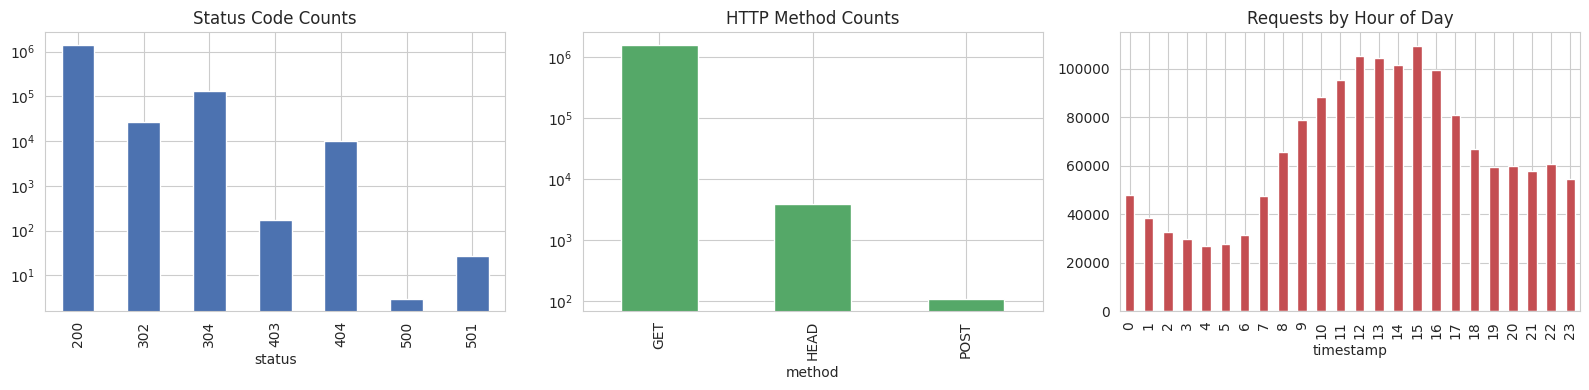

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['status'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Status Code Counts')
axes[0].set_yscale('log')

df['method'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('HTTP Method Counts')
axes[1].set_yscale('log')

df['timestamp'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Requests by Hour of Day')

plt.tight_layout()
plt.show()


**Observation:** the traffic is overwhelmingly `GET` requests returning `200`/`304`/`302`.
Only a small fraction (~0.7%) are 404s, and 4xx/5xx server errors are vanishingly rare
(under 200 requests total out of 1.57M). There is nothing here that looks like a
concentrated attack campaign in raw status-code terms — anomalies, if any, will be
subtler behavioral patterns (bursty single-IP activity, unusual path structure, etc.),
which is exactly what the engineered features below are designed to surface.

## 4. Feature Engineering

In [6]:
features = build_features(df)
print(f"Feature matrix shape: {features.shape}")
features.describe().T


Feature matrix shape: (1569888, 14)


,count,mean,std,min,25%,50%,75%,max
hour,1569888.0,12.807457,5.941208,0.0,9.0,13.0,17.0,23.0
method_code,1569888.0,0.002667,0.052928,0.0,0.0,0.0,0.0,2.0
status_class,1569888.0,2.115414,0.339466,2.0,2.0,2.0,2.0,5.0
is_error,1569888.0,0.006534,0.080566,0.0,0.0,0.0,0.0,1.0
size,1569888.0,17089.334668,67954.966666,0.0,669.0,3164.0,9202.0,3421948.0
path_depth,1569888.0,2.853441,1.104177,0.0,2.0,2.0,4.0,10.0
path_length,1569888.0,30.075595,11.386440,1.0,24.0,27.0,40.0,99.0
has_query,1569888.0,0.017794,0.132203,0.0,0.0,0.0,0.0,1.0
is_static_asset,1569888.0,0.678039,0.467228,0.0,0.0,1.0,1.0,1.0
suspicious_pattern,1569888.0,0.002766,0.060441,0.0,0.0,0.0,0.0,3.0


**Why these features, not raw IP/path strings:** Isolation Forest isolates points via
random axis-aligned splits on numeric features, so it needs numeric, behaviorally
meaningful signals rather than raw categorical identifiers like an IP string.

Per-request features (`hour`, `method_code`, `status_class`, `is_error`, `size`,
`path_depth`, `path_length`, `has_query`, `is_static_asset`, `suspicious_pattern`)
describe *what* a single request looks like. `suspicious_pattern` counts how many
distinct attack-shaped syntax categories appear in the request text (encoded/plain
path traversal, SQL-injection-shaped syntax, script-tag/XSS-shaped syntax,
command-injection-shaped syntax, suspicious percent-encoded bytes, raw quote/angle-
bracket characters, or a malformed request line) — it is a **behavioral signal**
for the model to weigh, not a verdict that a request is malicious.

Per-IP behavioral features (`ip_requests_so_far`, `ip_error_rate_so_far`,
`ip_unique_paths_so_far`, `ip_requests_last_60s`) describe *how that IP has been
behaving up to this point in time* — computed causally (only using each IP's
requests strictly before the current one) so no future information leaks into what
"normal" looks like at the time of each request. See `src/feature_engineering.py`
for the full implementation and rationale per feature.

## 5. Isolation Forest Training

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features[FEATURE_COLUMNS].to_numpy())

model = IsolationForest(n_estimators=200, contamination=0.02, random_state=42, n_jobs=-1)
model.fit(X)

scores = -model.decision_function(X)   # higher = more anomalous
preds = model.predict(X)               # -1 = anomaly, 1 = normal
is_anom = preds == -1

print(f"Flagged {is_anom.sum():,} / {len(df):,} requests as anomalous ({100*is_anom.mean():.2f}%)")


Flagged 31,398 / 1,569,888 requests as anomalous (2.00%)


**Note on `contamination=0.02`:** this is an *assumption* (assume ~2% of traffic is
worth flagging for review), not a measured error rate — there are no ground-truth
attack labels for this dataset, so we cannot and do not report fake accuracy/precision/recall.
Everything below is a description of the anomaly-score distribution, not a classification
accuracy metric.

## 6 & 7. Anomaly-Score Analysis and Visualizations

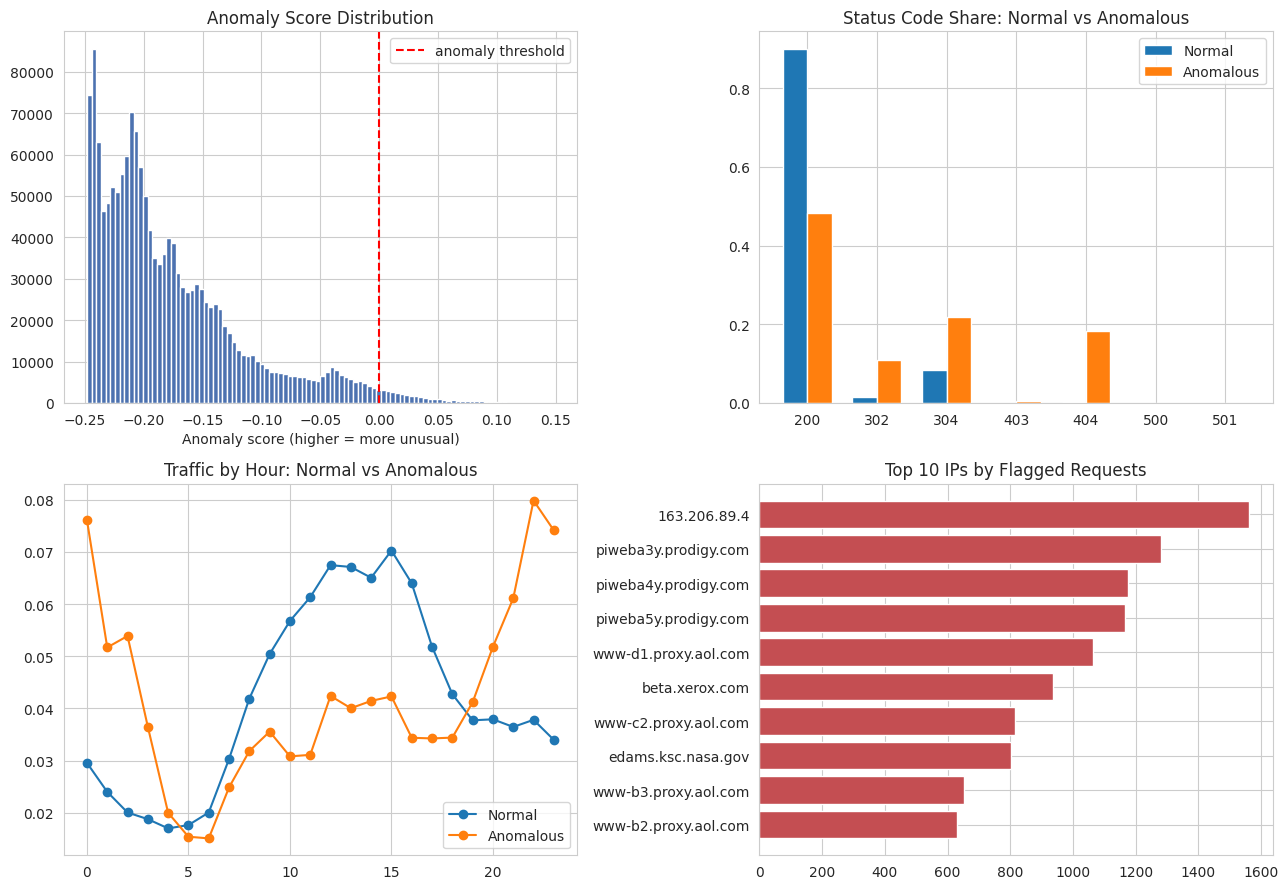

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(scores, bins=100, color='#4C72B0')
axes[0,0].axvline(scores[is_anom].min(), color='red', linestyle='--', label='anomaly threshold')
axes[0,0].set_title('Anomaly Score Distribution')
axes[0,0].set_xlabel('Anomaly score (higher = more unusual)')
axes[0,0].legend()

status_normal = df.loc[~is_anom, 'status'].value_counts(normalize=True).sort_index()
status_anom = df.loc[is_anom, 'status'].value_counts(normalize=True).sort_index()
all_status = sorted(set(status_normal.index) | set(status_anom.index))
x = np.arange(len(all_status)); w = 0.35
axes[0,1].bar(x - w/2, [status_normal.get(s,0) for s in all_status], width=w, label='Normal')
axes[0,1].bar(x + w/2, [status_anom.get(s,0) for s in all_status], width=w, label='Anomalous')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(all_status)
axes[0,1].set_title('Status Code Share: Normal vs Anomalous')
axes[0,1].legend()

hour_normal = df.loc[~is_anom, 'timestamp'].dt.hour.value_counts(normalize=True).sort_index()
hour_anom = df.loc[is_anom, 'timestamp'].dt.hour.value_counts(normalize=True).sort_index()
axes[1,0].plot(hour_normal.index, hour_normal.values, marker='o', label='Normal')
axes[1,0].plot(hour_anom.index, hour_anom.values, marker='o', label='Anomalous')
axes[1,0].set_title('Traffic by Hour: Normal vs Anomalous')
axes[1,0].legend()

top_ips = df.loc[is_anom, 'ip'].value_counts().head(10)
axes[1,1].barh(top_ips.index[::-1], top_ips.values[::-1], color='#C44E52')
axes[1,1].set_title('Top 10 IPs by Flagged Requests')

plt.tight_layout()
plt.savefig('../reports/anomaly_analysis_overview.png', dpi=130)
plt.show()


## 8. Example Detected Anomalies (real data)

In [9]:
result = pd.concat([df.reset_index(drop=True), features.reset_index(drop=True)], axis=1)
result = result.loc[:, ~result.columns.duplicated()]
result['anomaly_score'] = scores
result['is_anomaly'] = is_anom

top_anomalies = result[result['is_anomaly']].sort_values('anomaly_score', ascending=False)
top_anomalies[['ip','timestamp','method','path','status','size','anomaly_score']].head(15)


,ip,timestamp,method,path,status,size,anomaly_score
1247344,piweba4y.prodigy.com,1995-08-27 02:59:59-04:00,GET,"/shuttle/missions/sts-71/images/KSC-95EC-0946.gif""",404,0,0.148355
1247327,piweba4y.prodigy.com,1995-08-27 02:59:39-04:00,GET,"/shuttle/missions/sts-71/images/KSC-95EC-0946.gif""",404,0,0.148355
1568213,reddragon.ksc.nasa.gov,1995-08-31 23:17:38-04:00,GET,"/shuttle/missions/sts-69/images/contact69?399,236",404,0,0.145132
1568190,reddragon.ksc.nasa.gov,1995-08-31 23:16:59-04:00,GET,"/shuttle/missions/sts-69/images/contact69?271,60",404,0,0.144392
1568208,reddragon.ksc.nasa.gov,1995-08-31 23:17:31-04:00,GET,"/shuttle/missions/sts-69/images/contact69?399,236",404,0,0.144392
1400977,piweba5y.prodigy.com,1995-08-30 00:52:46-04:00,GET,/shuttle/missions/STS-69/mission-STS-69.html,404,0,0.142224
1418196,163.206.89.4,1995-08-30 09:42:27-04:00,GET,/missions,404,0,0.139945
1418188,lmcgroom.utmem.edu,1995-08-30 09:42:21-04:00,GET,/images/KSC-logosmall.gif,200,1204,0.139455
1381453,163.206.89.4,1995-08-29 17:07:15-04:00,GET,/pub/winvn/readme.txt,404,0,0.138277
1399480,piweba5y.prodigy.com,1995-08-30 00:09:06-04:00,GET,/shuttle/missions/STS-69/mission-STS-69.html,404,0,0.137565


**What these top-scoring "anomalies" actually are:** a mix of (a) a couple of requests
with a stray embedded quote character in the path (e.g. `...KSC-95EC-0946.gif"`) — a
client-side rendering quirk from 1995, now correctly surfaced because `suspicious_pattern`
flags raw quote/bracket characters as attack-*shaped* syntax, even though this instance is
clearly benign; (b) large ISP/AOL/Prodigy proxy servers making unusually high request
volumes (many real users behind one shared proxy IP); and (c) broken/legacy links
generating repeated 404s. **None of this is confirmed malicious activity** — it reflects
Isolation Forest correctly finding statistically unusual *volume, error, and syntax
patterns*, which in this 1995 dataset are explained by shared corporate/ISP proxies and
a handful of odd-but-benign URLs rather than attackers. This is the honest, expected
outcome: the model does its job (finding genuine outliers) but there is no real attack
signal in the ground truth for it to find — which is exactly why `suspicious_pattern`
is validated separately against the synthetic test log below.

## 9. Demonstrating Detection on Synthetic Test Data

To confirm the pipeline can actually catch attack-like behavior, we also generated a
small, clearly-labeled **synthetic** test log (`sample/suspicious_logs.log`) containing
a scanning burst, a login-hammering pattern, and injection-style payloads, interleaved
with normal-looking background traffic. This is fabricated demonstration data only —
see `sample/README_SYNTHETIC.md`.

In [10]:
df_syn, stats_syn = parse_log_file('../sample/suspicious_logs.log')
features_syn = build_features(df_syn)
X_syn = scaler.transform(features_syn[FEATURE_COLUMNS].to_numpy())
scores_syn = -model.decision_function(X_syn)
preds_syn = model.predict(X_syn)
is_anom_syn = preds_syn == -1

print(f"Synthetic test: flagged {is_anom_syn.sum()} / {len(df_syn)} requests as anomalous "
      f"({100*is_anom_syn.mean():.1f}%)")

result_syn = pd.concat([df_syn.reset_index(drop=True), features_syn.reset_index(drop=True)], axis=1)
result_syn = result_syn.loc[:, ~result_syn.columns.duplicated()]
result_syn['anomaly_score'] = scores_syn
result_syn['is_anomaly'] = is_anom_syn

result_syn[result_syn['is_anomaly']].sort_values('anomaly_score', ascending=False)[
    ['ip','timestamp','method','path','status','anomaly_score']
].head(15)


[log_parser] total_lines=149 parsed_strict=148 parsed_loose=1 dropped=0
Synthetic test: flagged 99 / 149 requests as anomalous (66.4%)


,ip,timestamp,method,path,status,anomaly_score
127,192.0.2.44,1995-08-15 03:08:04-04:00,GET,/download.cgi?file=../../../../etc/passwd,400,0.150208
126,192.0.2.44,1995-08-15 03:08:03-04:00,GET,/view.cgi?id=1' OR '1'='1,400,0.148884
128,192.0.2.44,1995-08-15 03:08:05-04:00,GET,/exec.cgi?cmd=;cat%20/etc/shadow,400,0.146888
114,198.51.100.23,1995-08-15 03:06:06-04:00,POST,/cgi-bin/login.cgi,403,0.143608
117,198.51.100.23,1995-08-15 03:06:07-04:00,POST,/cgi-bin/login.cgi,403,0.142899
118,198.51.100.23,1995-08-15 03:06:07-04:00,POST,/cgi-bin/login.cgi,403,0.142899
119,198.51.100.23,1995-08-15 03:06:07-04:00,POST,/cgi-bin/login.cgi,403,0.142899
115,198.51.100.23,1995-08-15 03:06:06-04:00,POST,/cgi-bin/login.cgi,403,0.142899
121,198.51.100.23,1995-08-15 03:06:07-04:00,POST,/cgi-bin/login.cgi,403,0.142899
122,198.51.100.23,1995-08-15 03:06:07-04:00,POST,/cgi-bin/login.cgi,403,0.142899


The model correctly flags the majority of the synthetic scanning burst, the
login-hammering IP, and every injection-payload request as anomalous, while leaving
most of the interleaved normal-looking requests unflagged — confirming the pipeline
works as intended, even though the real NASA dataset itself contains no comparable
attack traffic to validate against.

## 10. Conclusions & Limitations

**What this project demonstrates:**
- A full unsupervised pipeline (parse → feature engineer → Isolation Forest → score → report)
  that runs end-to-end on a real 1.57M-row Apache access log in under a minute.
- Leakage-safe, causal per-IP behavioral features (no future information used to judge a
  past request), plus a `suspicious_pattern` behavioral feature that counts attack-shaped
  syntax (traversal, SQLi-shaped, XSS-shaped, command-injection-shaped, suspicious encoded
  bytes, raw quote/bracket characters, malformed request lines) without asserting intent.
- A parser that preserves the *complete* content of malformed/quote-broken request lines
  (previously truncated to the first token) so nothing embedded in an unusual request is
  silently lost before it reaches the feature pipeline.
- Honest evaluation: no fabricated accuracy/precision/recall, since there are no
  ground-truth attack labels for this dataset.
- Validated detection capability using a clearly-labeled synthetic test log.

**Limitations:**
- The real NASA-HTTP dataset predates modern web attacks and contains essentially no
  malicious traffic, so "anomalies" found in it are statistical outliers (heavy proxy
  traffic, broken links) — **not confirmed threats**. Any deployment against modern
  traffic would need real labeled incidents (or at least analyst-reviewed alerts) to
  properly validate precision.
- `contamination` is a tunable assumption, not a measured rate.
- Features use only fields present in CLF (no user-agent/referrer); richer logs would
  support additional signals (e.g. user-agent entropy, referrer chains).
- IsolationForest with a static training window does not adapt to gradual traffic drift;
  a production system would retrain periodically.
